## RFM

In [1]:
# =============================================================================
# 1. Импорт библиотек и загрузка данных
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_parquet('cleaned_data.parquet')
orders = pd.read_parquet('orders.parquet')

In [2]:
# =============================================================================
# 2. Обогащение заказов категориями товаров
# =============================================================================
# (список уникальных категорий)
order_categories = df.groupby('order_uuid')['product_category'].apply(lambda x: list(x.unique())).reset_index()
order_categories.columns = ['order_uuid', 'categories_list']
orders = orders.merge(order_categories, on='order_uuid', how='left')

print(f"Уникальных заказов: {len(orders)}")
print(f"Пример:\n{orders[['order_uuid', 'client_uuid', 'total_amount', 'categories_list']].head(3)}")

Уникальных заказов: 182368
Пример:
                             order_uuid                           client_uuid  \
0  00002389-0c84-3b6f-1c26-53b2bcef2c83  00fa7eab-1304-e85e-e183-72b5319bac28   
1  00006058-087a-c430-4962-a3065cc4ea59  f90bf504-55a4-6125-9dd1-a767b8d59fe3   
2  0000cffe-a087-eea8-644f-a72f8bd304d8  54bb260f-56d5-2537-1f7b-ca6bf9e18b81   

   total_amount                                    categories_list  
0        123.20                             [Мобильные устройства]  
1        675.40  [Строительные материалы, Электронные компонент...  
2       1090.25                             [Мобильные устройства]  


In [3]:
# =============================================================================
# 3. Проверка качества данных orders
# =============================================================================
# Проверка 1: уникальность заказов
assert orders['order_uuid'].is_unique, "Есть дубликаты order_uuid!"
print("Уникальных заказов:", len(orders))

# Проверка 2: пропуски в ключевых полях
print("Пропуски в order_uuid:", orders['order_uuid'].isnull().sum())
print("Пропуски в client_uuid:", orders['client_uuid'].isnull().sum())
print("Пропуски в total_amount:", orders['total_amount'].isnull().sum())

# Проверка 3: сумма total_amount должна быть >0 (кроме нулевых заказов)
print("Минимальная сумма:", orders['total_amount'].min())
print("Максимальная сумма:", orders['total_amount'].max())
print("Доля нулевых заказов:", (orders['total_amount'] == 0).mean())

Уникальных заказов: 182368
Пропуски в order_uuid: 0
Пропуски в client_uuid: 0
Пропуски в total_amount: 0
Минимальная сумма: 0.0
Максимальная сумма: 26698599.23054905
Доля нулевых заказов: 0.004540270222846113


In [4]:
# =============================================================================
# 4. Винзоризация суммы заказа и флаг крупных заказов
# =============================================================================
p99_order = orders['total_amount'].quantile(0.99)
print(f"99-й процентиль суммы заказа: {p99_order:.2f} USD")

orders['amount_wins'] = orders['total_amount'].clip(upper=p99_order)   # винзоризированная сумма
orders['is_large_order'] = (orders['total_amount'] > p99_order).astype(int)

99-й процентиль суммы заказа: 42568.20 USD


In [5]:
# =============================================================================
# 5. Определение дат среза (cutoff) для train и test
# =============================================================================
max_date = df['order_dttm'].max()
print('Макс. дата в данных:', max_date)

# Тестовый снимок: последние 375 дней истории отложены как "будущее"
cutoff_test = (max_date - pd.Timedelta(days=375)).normalize()

# Тренировочный снимок - более ранняя точка отсчёта, чтобы train и test были разнесены во времени
GAP_DAYS = 150
cutoff_train = (cutoff_test - pd.Timedelta(days=GAP_DAYS)).normalize()

cutoffs = {'train': cutoff_train, 'test': cutoff_test}

print('Дата среза train:', cutoff_train)
print('Дата среза test :', cutoff_test)

Макс. дата в данных: 2026-06-11 19:44:46
Дата среза train: 2025-01-02 00:00:00
Дата среза test : 2025-06-01 00:00:00


In [6]:
# =============================================================================
# 6. Разделение данных на историю и будущее по cutoff
# =============================================================================
history_by_split = {}
future_by_split = {}

for split, cutoff_date in cutoffs.items():
    history_mask = df['order_dttm'] < cutoff_date
    future_mask = df['order_dttm'] >= cutoff_date

    history_by_split[split] = df[history_mask].copy()
    future_by_split[split] = df[future_mask].copy()

    print(f"[{split}] cutoff={cutoff_date.date()}: "
          f"клиентов с историей = {history_by_split[split]['client_uuid'].nunique()}, "
          f"строк истории = {len(history_by_split[split])}, "
          f"строк будущего = {len(future_by_split[split])}")
    #глубина истории для контроля адекватности среза
    hist = history_by_split[split]
    span_days = (hist['order_dttm'].max() - hist['order_dttm'].min()).days if len(hist) else 0
    print(f"[{split}] глубина истории (мин-макс дата в истории): {span_days} дней")

[train] cutoff=2025-01-02: клиентов с историей = 13368, строк истории = 178072, строк будущего = 362115
[train] глубина истории (мин-макс дата в истории): 362 дней
[test] cutoff=2025-06-01: клиентов с историей = 16203, строк истории = 242907, строк будущего = 297280
[test] глубина истории (мин-макс дата в истории): 514 дней


In [7]:
# =============================================================================
# 7. Доли категорий товаров по клиентам (история)
# =============================================================================
category_dummies_by_split = {}

for split, history_df in history_by_split.items():
    cd = history_df.groupby('client_uuid')['product_category'].value_counts(normalize=True).unstack(fill_value=0)
    cd.columns = [f'cat_share_{col}' for col in cd.columns]
    category_dummies_by_split[split] = cd.reset_index()
    print(f"[{split}] category_dummies: {category_dummies_by_split[split].shape}")

[train] category_dummies: (13368, 20)
[test] category_dummies: (16203, 20)


90-й перцентиль: 40.0 дней
95-й перцентиль: 111.0 дней
99-й перцентиль: 250.0 дней


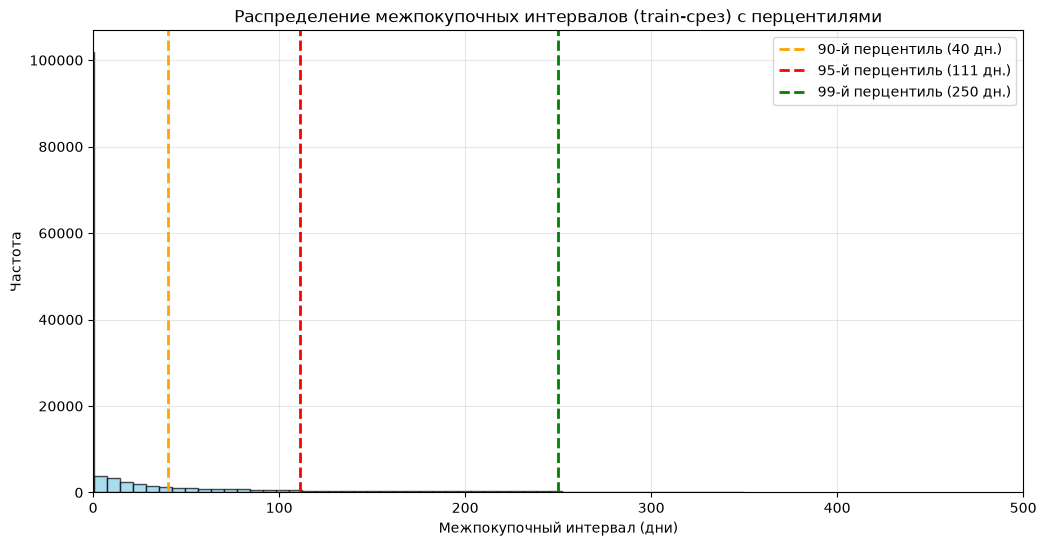

Используемый порог оттока (единый для train и test): 111 дней


In [8]:
# =============================================================================
# 8. Анализ межпокупочных интервалов и выбор перцентилей
# =============================================================================
history_train = history_by_split['train']

client_orders = history_train.groupby('client_uuid')['order_dttm'].apply(list).reset_index()
client_orders['intervals'] = client_orders['order_dttm'].apply(
    lambda dates: [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)] if len(dates) > 1 else []
)
all_intervals = [item for sublist in client_orders['intervals'] for item in sublist]

p90 = np.percentile(all_intervals, 90)
p95 = np.percentile(all_intervals, 95)
p99 = np.percentile(all_intervals, 99)
print(f'90-й перцентиль: {p90:.1f} дней')
print(f'95-й перцентиль: {p95:.1f} дней')
print(f'99-й перцентиль: {p99:.1f} дней')

plt.figure(figsize=(12, 6))
plt.hist(all_intervals, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(p90, color='orange', linestyle='--', linewidth=2, label=f'90-й перцентиль ({p90:.0f} дн.)')
plt.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'95-й перцентиль ({p95:.0f} дн.)')
plt.axvline(p99, color='green', linestyle='--', linewidth=2, label=f'99-й перцентиль ({p99:.0f} дн.)')
plt.xlabel('Межпокупочный интервал (дни)')
plt.ylabel('Частота')
plt.title('Распределение межпокупочных интервалов (train-срез) с перцентилями')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 500)
plt.show()

churn_threshold_days = int(p95)
print(f'Используемый порог оттока (единый для train и test): {churn_threshold_days} дней')

In [9]:
# =============================================================================
# 9. Формирование целевой переменной churn и обоснование порога
# =============================================================================
target_by_split = {}

for split in ['train', 'test']:
    cutoff_date = cutoffs[split]
    history_df = history_by_split[split]
    future_df = future_by_split[split]

    future_client_orders = future_df.groupby('client_uuid')['order_dttm'].min().reset_index()
    future_client_orders.columns = ['client_uuid', 'first_future_order']

    all_clients = history_df['client_uuid'].unique()
    target_df = pd.DataFrame({'client_uuid': all_clients})
    target_df = target_df.merge(future_client_orders, on='client_uuid', how='left')

    target_df['churn'] = (
        (target_df['first_future_order'].isna()) |
        (target_df['first_future_order'] > cutoff_date + pd.Timedelta(days=churn_threshold_days))
    ).astype(int)

    target_by_split[split] = target_df
    print(f"[{split}] доля оттока при пороге {churn_threshold_days} дней: {target_df['churn'].mean():.2%}")

print('\n===== Обоснование выбора 95-го перцентиля (по train-срезу) =====')
print(f'• 90-й перцентиль ({p90:.0f} дн.) слишком мал – завышает долю оттока, добавляет шум.')
print(f'• 95-й перцентиль ({p95:.0f} дн.) – консервативное определение, ≈5 месяцев без заказов.')
print(f'• 99-й перцентиль ({p99:.0f} дн.) слишком жёсткий – упускает часть реально ушедших.')
print('Порог фиксируется один раз и применяется одинаково к train и test срезам.')

[train] доля оттока при пороге 111 дней: 70.67%
[test] доля оттока при пороге 111 дней: 70.84%

===== Обоснование выбора 95-го перцентиля (по train-срезу) =====
• 90-й перцентиль (40 дн.) слишком мал – завышает долю оттока, добавляет шум.
• 95-й перцентиль (111 дн.) – консервативное определение, ≈5 месяцев без заказов.
• 99-й перцентиль (250 дн.) слишком жёсткий – упускает часть реально ушедших.
Порог фиксируется один раз и применяется одинаково к train и test срезам.


In [10]:
# =============================================================================
# 10. Базовые RFM-признаки
# =============================================================================
model_data_by_split = {}

for split in ['train', 'test']:
    cutoff_date = cutoffs[split]
    history_df = history_by_split[split]

    rfm = history_df.groupby('client_uuid').agg(
        recency_days=('order_dttm', lambda x: (cutoff_date - x.max()).days),
        frequency=('order_uuid', 'nunique'),
        monetary_sum=('amount_usd', 'sum'),
        monetary_mean=('amount_usd', 'mean'),
        monetary_std=('amount_usd', 'std'),
        days_active=('order_dttm', lambda x: (x.max() - x.min()).days if len(x) > 1 else 0)
    ).reset_index()
    rfm.fillna({'monetary_std': 0}, inplace=True)

    cat_count = history_df.groupby('client_uuid')['product_category'].nunique().reset_index()
    cat_count.columns = ['client_uuid', 'unique_categories']
    prod_count = history_df.groupby('client_uuid')['product_uuid'].nunique().reset_index()
    prod_count.columns = ['client_uuid', 'unique_products']

    rfm = rfm.merge(cat_count, on='client_uuid', how='left').merge(prod_count, on='client_uuid', how='left')

    model_data = target_by_split[split].merge(rfm, on='client_uuid', how='inner')
    model_data_by_split[split] = model_data
    print(f"[{split}] после базового RFM: {model_data.shape}")

[train] после базового RFM: (13368, 11)
[test] после базового RFM: (16203, 11)


In [11]:
# =============================================================================
# 11. Функции для оконных статистик и recency по окнам
# =============================================================================
windows = [30, 60, 90, 180, 365]

def calc_window_stats(df, window_days, cutoff_date):
    start_date = cutoff_date - pd.Timedelta(days=window_days)
    mask = df['order_dttm'] >= start_date
    recent = df[mask]
    stats = recent.groupby('client_uuid').agg(
        freq=('order_uuid', 'nunique'),
        sum_amount=('amount_usd', 'sum'),
        mean_amount=('amount_usd', 'mean'),
        std_amount=('amount_usd', 'std'),
        min_amount=('amount_usd', 'min'),
        max_amount=('amount_usd', 'max'),
        active_days=('order_dttm', lambda x: x.dt.date.nunique())
    ).reset_index()
    rename = {col: f'{col}_{window_days}d' for col in stats.columns if col != 'client_uuid'}
    stats.rename(columns=rename, inplace=True)
    return stats

def calc_recency_for_window(df, cutoff_date, window_days):
    start_date = cutoff_date - pd.Timedelta(days=window_days)
    recent = df[df['order_dttm'] >= start_date].groupby('client_uuid')['order_dttm'].max().reset_index()
    recent.columns = ['client_uuid', f'last_order_{window_days}d']
    recent[f'recency_{window_days}d'] = (cutoff_date - recent[f'last_order_{window_days}d']).dt.days
    return recent[['client_uuid', f'recency_{window_days}d']]

In [12]:
# =============================================================================
# 12. Расчёт оконных статистик (30/60/90/180/365 дней)
# =============================================================================
for split in ['train', 'test']:
    cutoff_date = cutoffs[split]
    history_df = history_by_split[split]
    model_data = model_data_by_split[split]

    all_stats = None
    for w in windows:
        stats_ = calc_window_stats(history_df, w, cutoff_date)
        all_stats = stats_ if all_stats is None else all_stats.merge(stats_, on='client_uuid', how='outer')
    for w in windows:
        rec = calc_recency_for_window(history_df, cutoff_date, w)
        all_stats = all_stats.merge(rec, on='client_uuid', how='left')
    for col in all_stats.columns:
        if col != 'client_uuid':
            all_stats[col] = all_stats[col].fillna(0)

    model_data = model_data.merge(all_stats, on='client_uuid', how='left')

    rename_dict = {}
    for w in windows:
        for stat in ['sum', 'mean', 'std', 'min', 'max']:
            old, new = f'{stat}_amount_{w}d', f'{stat}_{w}d'
            if old in model_data.columns:
                rename_dict[old] = new
    model_data.rename(columns=rename_dict, inplace=True)

    model_data_by_split[split] = model_data
    print(f"[{split}] после оконных статистик: {model_data.shape}")

[train] после оконных статистик: (13368, 51)
[test] после оконных статистик: (16203, 51)


In [13]:
# =============================================================================
# 13. Клиентские атрибуты и агрегаты по amount_wins
# =============================================================================
for split in ['train', 'test']:
    cutoff_date = cutoffs[split]
    model_data = model_data_by_split[split]
    orders_hist = orders[orders['order_date'] < cutoff_date].copy()

    client_attrs = orders_hist[['client_uuid', 'client_type', 'country', 'okved', 'ecom_flg']].drop_duplicates('client_uuid')
    agg_orders = orders_hist.groupby('client_uuid').agg(
        avg_amount_wins=('amount_wins', 'mean'),
        max_amount_wins=('amount_wins', 'max'),
        large_order_share=('is_large_order', 'mean')
    ).reset_index()
    client_features = client_attrs.merge(agg_orders, on='client_uuid', how='left')

    model_data = model_data.merge(client_features, on='client_uuid', how='left')
    numeric_cols = ['avg_amount_wins', 'max_amount_wins', 'large_order_share']
    model_data[numeric_cols] = model_data[numeric_cols].fillna(0)

    model_data_by_split[split] = model_data
    print(f"[{split}] добавлены клиентские признаки (по истории до cutoff): {client_features.columns.tolist()}")

[train] добавлены клиентские признаки (по истории до cutoff): ['client_uuid', 'client_type', 'country', 'okved', 'ecom_flg', 'avg_amount_wins', 'max_amount_wins', 'large_order_share']
[test] добавлены клиентские признаки (по истории до cutoff): ['client_uuid', 'client_type', 'country', 'okved', 'ecom_flg', 'avg_amount_wins', 'max_amount_wins', 'large_order_share']


In [14]:
# =============================================================================
# 14. Производные и логарифмические признаки
# =============================================================================
for split in ['train', 'test']:
    model_data = model_data_by_split[split]

    for w in windows:
        model_data[f'freq_share_{w}d'] = model_data[f'freq_{w}d'] / (model_data['frequency'] + 1e-6)

    model_data['avg_interval_days'] = np.where(
        model_data['frequency'] > 1, model_data['days_active'] / (model_data['frequency'] - 1), 0)

    model_data['monetary_cv'] = np.where(
        model_data['monetary_mean'] > 0, model_data['monetary_std'] / model_data['monetary_mean'], 0)
    model_data['monetary_cv'] = model_data['monetary_cv'].replace([np.inf, -np.inf], 0)

    model_data['recent_order_share'] = np.where(
        model_data['frequency'] > 0, model_data['freq_90d'] / model_data['frequency'], 0)

    model_data['monetary_trend'] = model_data['mean_90d'] - model_data['monetary_mean']

    monetary_cols = [
        'monetary_sum', 'monetary_mean', 'monetary_std',
        'sum_30d', 'sum_60d', 'sum_90d', 'sum_180d', 'sum_365d',
        'mean_30d', 'mean_60d', 'mean_90d', 'mean_180d', 'mean_365d',
        'monetary_cv'
    ]
    for col in monetary_cols:
        model_data[f'log_{col}'] = np.log1p(model_data[col])

    model_data_by_split[split] = model_data
    print(f"[{split}] добавлены производные и логарифмические признаки")

[train] добавлены производные и логарифмические признаки
[test] добавлены производные и логарифмические признаки


In [15]:
# =============================================================================
# 15. Тренды частоты и суммы по окнам (slope, CV)
# =============================================================================
from scipy import stats

freq_cols = [f'freq_{w}d' for w in windows]
sum_cols = [f'sum_{w}d' for w in windows]
x = np.log(windows)

def slope_per_client(df, cols):
    slopes = []
    for row in df[cols].values:
        y = np.nan_to_num(np.array(row, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
        if np.all(y == 0):
            slopes.append(0.0)
        else:
            slope, _, _, _, _ = stats.linregress(x, y)
            slopes.append(slope)
    return slopes

for split in ['train', 'test']:
    model_data = model_data_by_split[split]

    for w in windows:
        for base_col in [f'freq_{w}d', f'sum_{w}d']:
            model_data[base_col] = pd.to_numeric(model_data[base_col], errors='coerce').fillna(0)
            log_col = f'log_{base_col}'
            model_data[log_col] = np.log1p(model_data[base_col])

    log_freq_cols = [f'log_{c}' for c in freq_cols]
    log_sum_cols = [f'log_{c}' for c in sum_cols]

    model_data['freq_trend_slope'] = slope_per_client(model_data, log_freq_cols)
    model_data['sum_trend_slope'] = slope_per_client(model_data, log_sum_cols)

    model_data['freq_cv_windows'] = model_data[freq_cols].std(axis=1) / (model_data[freq_cols].mean(axis=1) + 1e-6)
    model_data['sum_cv_windows'] = model_data[sum_cols].std(axis=1) / (model_data[sum_cols].mean(axis=1) + 1e-6)
    model_data[['freq_cv_windows', 'sum_cv_windows']] = model_data[['freq_cv_windows', 'sum_cv_windows']].replace([np.inf, -np.inf], 0)

    model_data_by_split[split] = model_data
    print(f"[{split}] добавлены freq_trend_slope, sum_trend_slope, freq_cv_windows, sum_cv_windows")

[train] добавлены freq_trend_slope, sum_trend_slope, freq_cv_windows, sum_cv_windows
[test] добавлены freq_trend_slope, sum_trend_slope, freq_cv_windows, sum_cv_windows


In [16]:
# =============================================================================
# 16. Квантили межпокупочных интервалов
# =============================================================================
def interval_quantiles(dates):
    if len(dates) < 2:
        return [np.nan, np.nan, np.nan]
    diffs = np.diff(sorted(dates))
    return np.percentile(diffs, [25, 50, 75])

for split in ['train', 'test']:
    history_df = history_by_split[split]
    model_data = model_data_by_split[split]

    client_intervals = history_df.groupby('client_uuid')['order_dttm'].apply(interval_quantiles).reset_index()
    client_intervals[['p25_interval', 'median_interval', 'p75_interval']] = pd.DataFrame(
        client_intervals['order_dttm'].tolist(), index=client_intervals.index)
    client_intervals.drop(columns=['order_dttm'], inplace=True)

    model_data = model_data.merge(client_intervals, on='client_uuid', how='left')
    for col in ['p25_interval', 'median_interval', 'p75_interval']:
        model_data[col] = model_data[col].fillna(model_data[col].median())

    model_data_by_split[split] = model_data
    print(f"[{split}] добавлены квантили межпокупочных интервалов")

[train] добавлены квантили межпокупочных интервалов
[test] добавлены квантили межпокупочных интервалов


In [17]:
# =============================================================================
# 17. Удаление служебных колонок
# =============================================================================
for split in ['train', 'test']:
    model_data = model_data_by_split[split]

    cols_to_drop = ['first_future_order']
    cols_to_drop += [c for c in model_data.columns if c.startswith('last_order_')]
    present = [c for c in cols_to_drop if c in model_data.columns]

    model_data.drop(columns=present, errors='ignore', inplace=True)
    model_data_by_split[split] = model_data
    print(f"[{split}] удалены служебные колонки: {present}")

[train] удалены служебные колонки: ['first_future_order']
[test] удалены служебные колонки: ['first_future_order']


In [18]:
# =============================================================================
# 18. Сезонные признаки (месяц / квартал)
# =============================================================================
for split in ['train', 'test']:
    history_df = history_by_split[split]
    model_data = model_data_by_split[split]

    month_dummies = history_df.groupby('client_uuid')['order_dttm'].apply(
        lambda x: x.dt.month.value_counts(normalize=True)).unstack(fill_value=0)
    month_dummies.columns = [f'month_share_{int(c)}' for c in month_dummies.columns]
    # ФИКС: гарантируем все 12 месяцев как колонки, даже если в истории не встретились
    for m in range(1, 13):
        col = f'month_share_{m}'
        if col not in month_dummies.columns:
            month_dummies[col] = 0.0
    month_dummies = month_dummies.reset_index()

    quarter_dummies = history_df.groupby('client_uuid')['order_dttm'].apply(
        lambda x: x.dt.quarter.value_counts(normalize=True)).unstack(fill_value=0)
    quarter_dummies.columns = [f'quarter_share_{int(c)}' for c in quarter_dummies.columns]
    # ФИКС: гарантируем все 4 квартала
    for q in range(1, 5):
        col = f'quarter_share_{q}'
        if col not in quarter_dummies.columns:
            quarter_dummies[col] = 0.0
    quarter_dummies = quarter_dummies.reset_index()

    model_data = model_data.merge(month_dummies, on='client_uuid', how='left')
    model_data = model_data.merge(quarter_dummies, on='client_uuid', how='left')

    numeric_cols = model_data.select_dtypes(include=['number']).columns
    model_data[numeric_cols] = model_data[numeric_cols].fillna(0)

    model_data_by_split[split] = model_data
    print(f"[{split}] сезонные признаки добавлены (все 12 месяцев / 4 квартала гарантированы)")

[train] сезонные признаки добавлены (все 12 месяцев / 4 квартала гарантированы)
[test] сезонные признаки добавлены (все 12 месяцев / 4 квартала гарантированы)


In [19]:
# =============================================================================
# 19. Объединение с долями категорий товаров
# =============================================================================
for split in ['train', 'test']:
    model_data = model_data_by_split[split].merge(category_dummies_by_split[split], on='client_uuid', how='left')
    model_data_by_split[split] = model_data
    print(f"[{split}] признаки долей категорий товаров объединены: {model_data.shape}")

[train] признаки долей категорий товаров объединены: (13368, 127)
[test] признаки долей категорий товаров объединены: (16203, 127)


In [20]:
# =============================================================================
# 20. Финальные проверки данных (дубликаты колонок, типы, отток)
# =============================================================================
for split in ['train', 'test']:
    model_data = model_data_by_split[split]
    print(f"[{split}] итоговый размер: {model_data.shape}")

    duplicates = model_data.columns[model_data.columns.duplicated()]
    if len(duplicates) > 0:
        print(f"[{split}] найдены дублирующиеся колонки:", duplicates.tolist())
        model_data = model_data.loc[:, ~model_data.columns.duplicated()]
        model_data_by_split[split] = model_data

    non_numeric = [c for c in model_data.select_dtypes(exclude=['number']).columns if c != 'client_uuid']
    if non_numeric:
        print(f"[{split}] нечисловые колонки:", non_numeric)
    else:
        print(f"[{split}] все колонки (кроме client_uuid) числовые ✅")

    print(f"[{split}] доля оттока: {model_data['churn'].mean():.2%}, "
          f"признаков (без client_uuid и churn): {len(model_data.columns) - 2}\n")

[train] итоговый размер: (13368, 127)
[train] нечисловые колонки: ['client_type', 'country', 'okved', 'ecom_flg']
[train] доля оттока: 70.67%, признаков (без client_uuid и churn): 125

[test] итоговый размер: (16203, 127)
[test] нечисловые колонки: ['client_type', 'country', 'okved', 'ecom_flg']
[test] доля оттока: 70.84%, признаков (без client_uuid и churn): 125



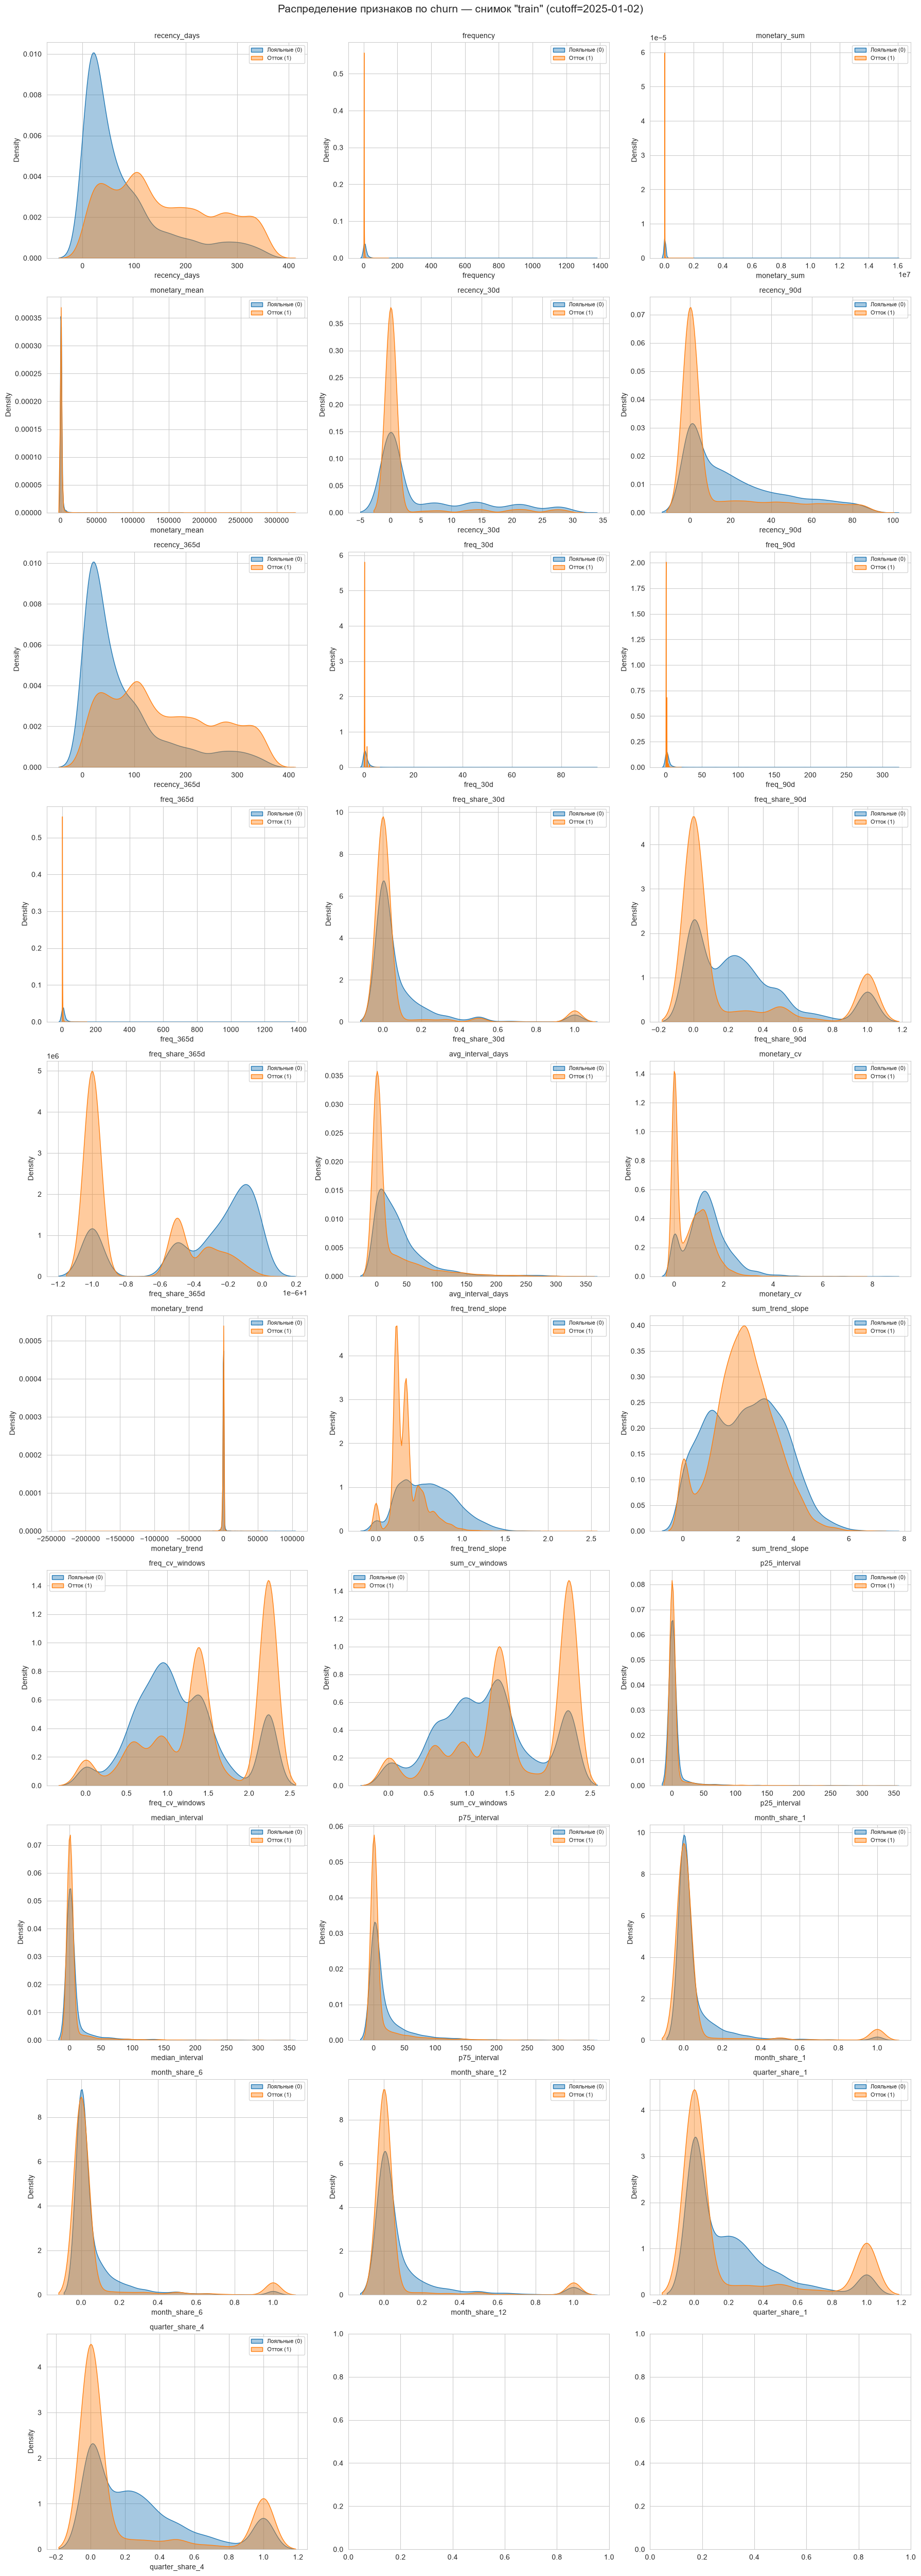

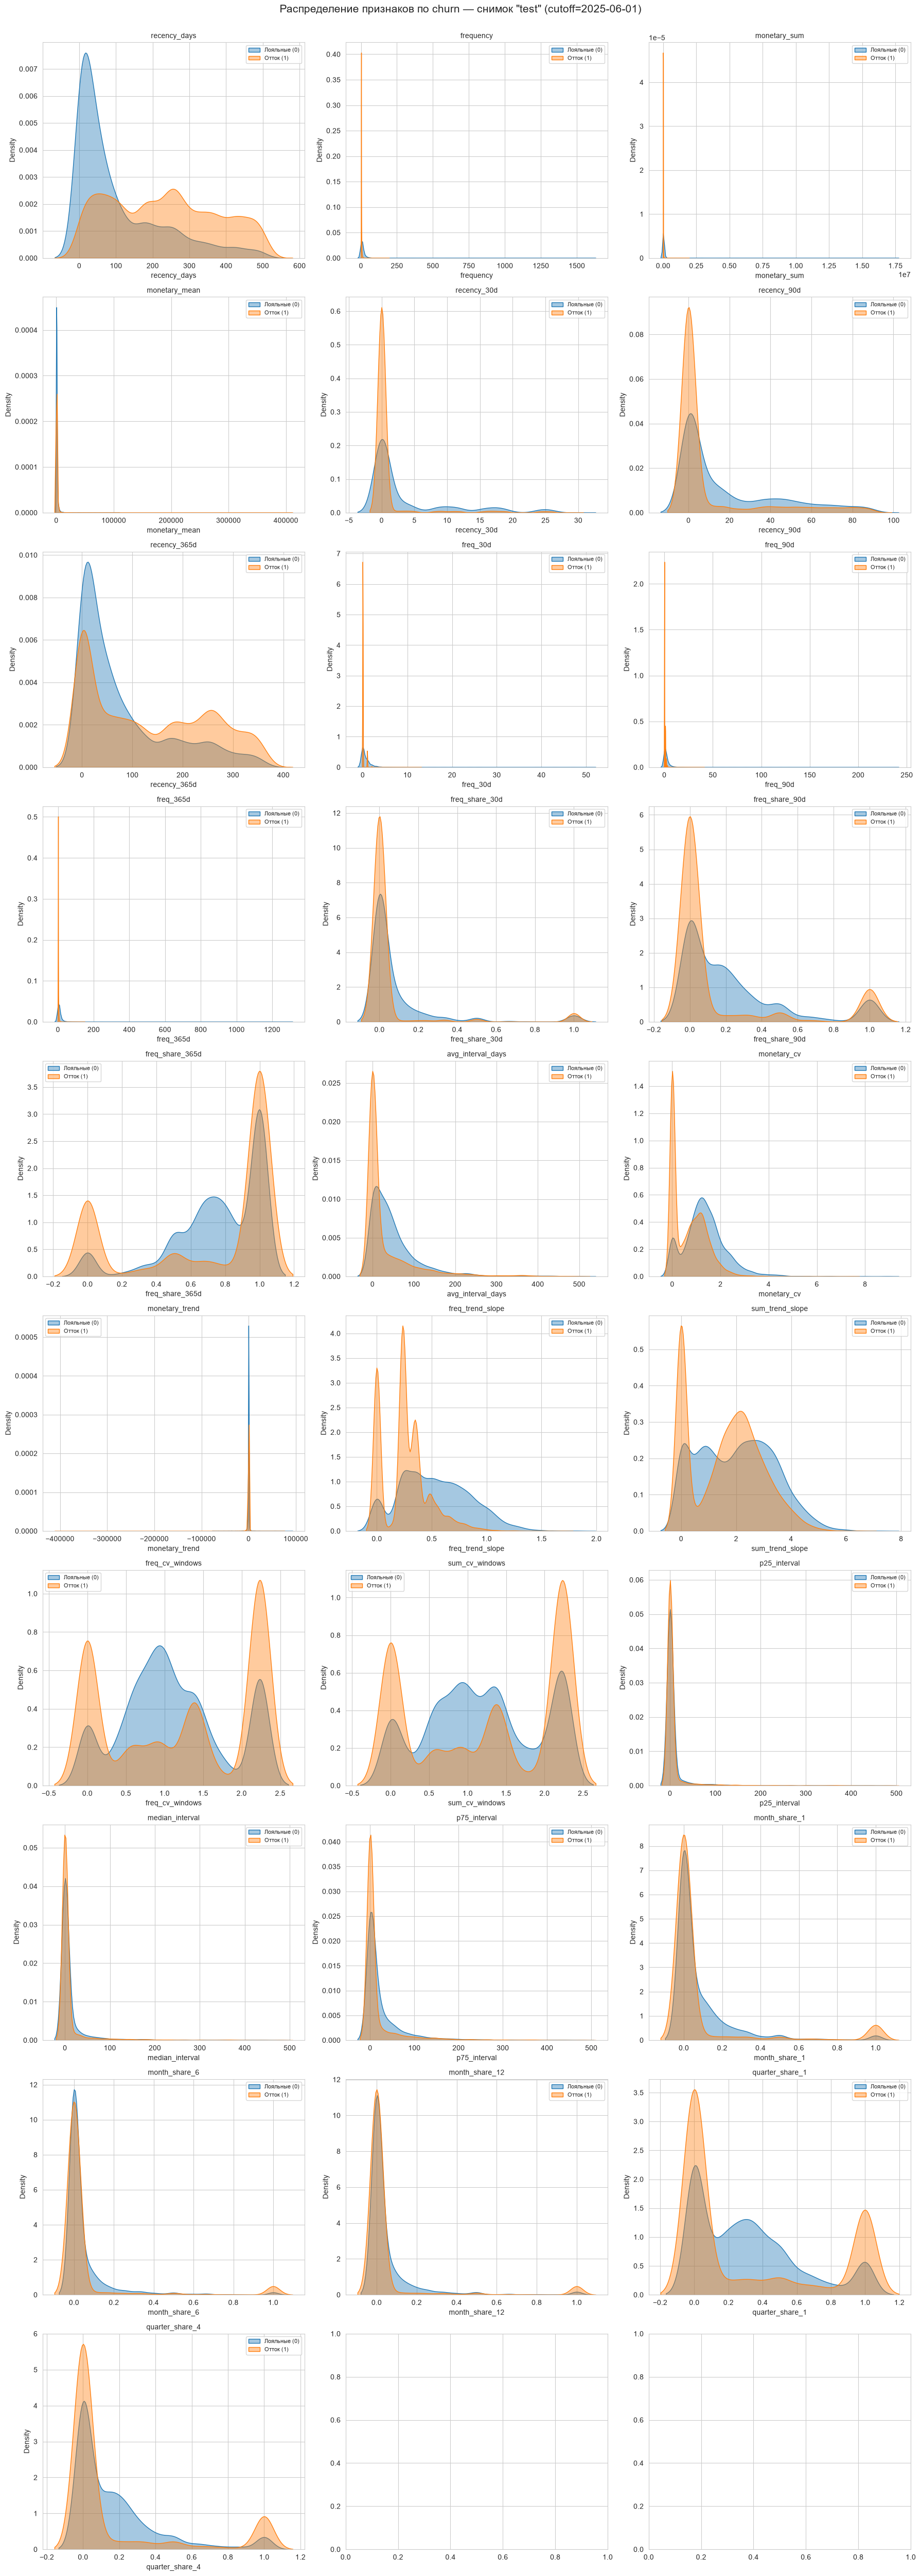

In [21]:
# =============================================================================
# 21. Визуализация распределений признаков по churn
# =============================================================================
import seaborn as sns
sns.set_style('whitegrid')

def convert_timedelta_to_days(s):
    if pd.api.types.is_timedelta64_dtype(s):
        return s.dt.total_seconds() / (24 * 3600)
    return s

features_to_plot = [
    'recency_days', 'frequency', 'monetary_sum', 'monetary_mean',
    'recency_30d', 'recency_90d', 'recency_365d',
    'freq_30d', 'freq_90d', 'freq_365d',
    'freq_share_30d', 'freq_share_90d', 'freq_share_365d',
    'avg_interval_days', 'monetary_cv', 'monetary_trend',
    'freq_trend_slope', 'sum_trend_slope',
    'freq_cv_windows', 'sum_cv_windows',
    'p25_interval', 'median_interval', 'p75_interval',
    'month_share_1', 'month_share_6', 'month_share_12',
    'quarter_share_1', 'quarter_share_4'
]

for split in ['train', 'test']:
    model_data = model_data_by_split[split]
    n_cols = 3
    n_rows = (len(features_to_plot) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, feat in enumerate(features_to_plot):
        if feat not in model_data.columns:
            continue
        ax = axes[i]
        data_0 = convert_timedelta_to_days(model_data.loc[model_data['churn'] == 0, feat])
        data_1 = convert_timedelta_to_days(model_data.loc[model_data['churn'] == 1, feat])
        sns.kdeplot(data_0, ax=ax, label='Лояльные (0)', fill=True, alpha=0.4)
        sns.kdeplot(data_1, ax=ax, label='Отток (1)', fill=True, alpha=0.4)
        ax.set_title(feat, fontsize=10)
        ax.legend(fontsize=8)

    fig.suptitle(f'Распределение признаков по churn — снимок "{split}" (cutoff={cutoffs[split].date()})', fontsize=15, y=1.001)
    plt.tight_layout()
    plt.show()

In [22]:
# =============================================================================
# 22. Объединение train/test и сохранение датасета
# =============================================================================
for split in ['train', 'test']:
    model_data_by_split[split]['data_split'] = split

model_data = pd.concat([model_data_by_split['train'], model_data_by_split['test']], ignore_index=True)

print(f"Итоговый объединённый датасет: {model_data.shape}")
print(model_data['data_split'].value_counts())

model_data.to_csv('model_data_after_rfm.csv', index=False)
print("model_data_after_rfm.csv сохранён (train+test, с колонкой data_split)")

C:\Users\imnot\AppData\Local\Temp\ipykernel_9896\3123630327.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_data_by_split[split]['data_split'] = split


Итоговый объединённый датасет: (29571, 128)
data_split
test     16203
train    13368
Name: count, dtype: int64
model_data_after_rfm.csv сохранён (train+test, с колонкой data_split)


In [23]:
# =============================================================================
# 23. Сохранение параметров пайплайна в JSON
# =============================================================================
import json

params = {
    'cutoff_train': str(cutoff_train),
    'cutoff_test': str(cutoff_test),
    'churn_threshold_days': churn_threshold_days,
    'categorical_features': ['client_type', 'country', 'okved', 'ecom_flg'],
    'target': 'churn',
    'client_id': 'client_uuid'
}

with open('model_params.json', 'w') as f:
    json.dump(params, f, default=str)
print("Параметры сохранены в model_params.json")

Параметры сохранены в model_params.json
